In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import BallTree

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

In [4]:
viirs_night = pd.read_csv(
    "viirs_night_2023_2024_eda.csv"
)

viirs_night["acq_date"] = pd.to_datetime(
    viirs_night["acq_date"],
    errors="coerce"
)

print("Shape:", viirs_night.shape)
print(
    "Date range:",
    viirs_night["acq_date"].min().date(),
    "to",
    viirs_night["acq_date"].max().date()
)

Shape: (323659, 18)
Date range: 2023-01-01 to 2024-12-31


In [5]:
spatial_eda = viirs_night[
    [
        "latitude",
        "longitude",
        "acq_date",
        "acq_time",
        "bright_ti4",
        "bright_ti5",
        "frp"
    ]
].copy()

spatial_eda = spatial_eda.dropna(
    subset=["latitude", "longitude", "acq_date"]
).reset_index(drop=True)

print("Working observations:", len(spatial_eda))

Working observations: 323659


In [6]:
unique_coords = (
    spatial_eda[
        ["latitude", "longitude"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Total observations:", len(spatial_eda))
print("Unique coordinates:", len(unique_coords))
print(
    "Repeated-coordinate observations:",
    len(spatial_eda) - len(unique_coords)
)

Total observations: 323659
Unique coordinates: 323532
Repeated-coordinate observations: 127


In [7]:
EARTH_RADIUS_KM = 6371.0088

coords_rad = np.radians(
    unique_coords[
        ["latitude", "longitude"]
    ].values
)

tree = BallTree(
    coords_rad,
    metric="haversine"
)

print("BallTree built successfully.")

BallTree built successfully.


In [8]:
distances, indices = tree.query(
    coords_rad,
    k=2
)

nearest_distance_km = (
    distances[:, 1]
    * EARTH_RADIUS_KM
)

unique_coords["nearest_distance_km"] = (
    nearest_distance_km
)

unique_coords[
    "nearest_distance_km"
].describe()

count   323532.0000
mean         0.4761
std          1.2535
min          0.0010
25%          0.0162
50%          0.1328
75%          0.4217
max        111.5330
Name: nearest_distance_km, dtype: float64

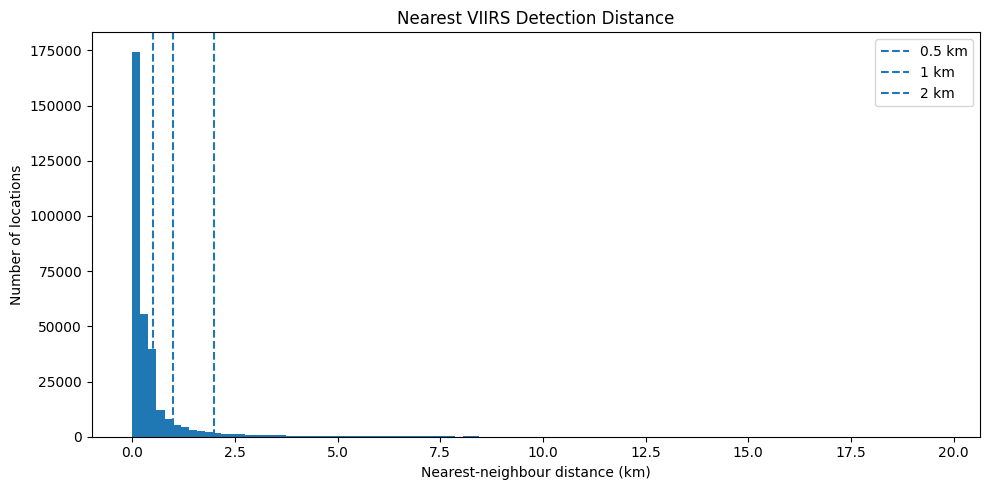

In [9]:
plt.figure(figsize=(10, 5))

plt.hist(
    unique_coords["nearest_distance_km"][
        unique_coords["nearest_distance_km"] <= 20
    ],
    bins=100
)

plt.axvline(
    0.5,
    linestyle="--",
    label="0.5 km"
)

plt.axvline(
    1.0,
    linestyle="--",
    label="1 km"
)

plt.axvline(
    2.0,
    linestyle="--",
    label="2 km"
)

plt.title(
    "Nearest VIIRS Detection Distance"
)

plt.xlabel("Nearest-neighbour distance (km)")
plt.ylabel("Number of locations")

plt.legend()
plt.tight_layout()
plt.show()

In [10]:
unique_coords[
    "nearest_distance_km"
].quantile(
    [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

0.0100   0.0024
0.0500   0.0057
0.1000   0.0084
0.2500   0.0162
0.5000   0.1328
0.7500   0.4217
0.9000   1.0332
0.9500   1.9665
0.9900   5.7768
Name: nearest_distance_km, dtype: float64

In [11]:
candidate_radii_km = [0.5, 1, 2, 5]

radius_results = []

for radius_km in candidate_radii_km:

    radius_rad = radius_km / EARTH_RADIUS_KM

    counts = tree.query_radius(
        coords_rad,
        r=radius_rad,
        count_only=True
    )

    # Remove the point itself
    neighbour_counts = counts - 1

    radius_results.append({
        "radius_km": radius_km,
        "mean_neighbours": neighbour_counts.mean(),
        "median_neighbours": np.median(neighbour_counts),
        "p75_neighbours": np.percentile(neighbour_counts, 75),
        "p90_neighbours": np.percentile(neighbour_counts, 90),
        "p95_neighbours": np.percentile(neighbour_counts, 95),
        "max_neighbours": neighbour_counts.max(),
        "isolated_locations": np.sum(
            neighbour_counts == 0
        )
    })

radius_results = pd.DataFrame(
    radius_results
)

display(radius_results)

,radius_km,mean_neighbours,median_neighbours,p75_neighbours,p90_neighbours,p95_neighbours,max_neighbours,isolated_locations
0,0.5000,233.4254,4.0000,404.0000,792.0000,1006.0000,1833,65041
1,1.0000,457.3867,10.0000,639.0000,1582.0000,2139.0000,4428,33340
2,2.0000,789.3267,23.0000,1003.0000,2751.0000,3454.0000,8596,15852
3,5.0000,1317.8888,82.0000,1528.0000,3364.0000,6922.4500,14381,4188


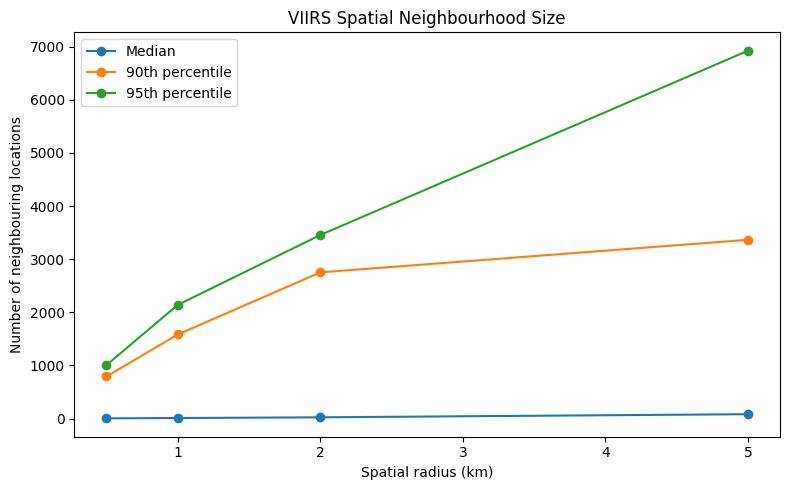

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    radius_results["radius_km"],
    radius_results["median_neighbours"],
    marker="o",
    label="Median"
)

plt.plot(
    radius_results["radius_km"],
    radius_results["p90_neighbours"],
    marker="o",
    label="90th percentile"
)

plt.plot(
    radius_results["radius_km"],
    radius_results["p95_neighbours"],
    marker="o",
    label="95th percentile"
)

plt.xlabel("Spatial radius (km)")
plt.ylabel("Number of neighbouring locations")

plt.title(
    "VIIRS Spatial Neighbourhood Size"
)

plt.legend()
plt.tight_layout()
plt.show()

In [13]:
SAMPLE_SIZE = 50000

spatial_sample = (
    spatial_eda
    .sample(
        n=min(SAMPLE_SIZE, len(spatial_eda)),
        random_state=42
    )
    .reset_index(drop=True)
)

print(
    "Spatial test sample:",
    len(spatial_sample)
)

Spatial test sample: 50000


In [14]:
sample_coords_rad = np.radians(
    spatial_sample[
        ["latitude", "longitude"]
    ].values
)

sample_tree = BallTree(
    sample_coords_rad,
    metric="haversine"
)

print("Sample BallTree ready.")

Sample BallTree ready.


In [15]:
same_day_results = []

for radius_km in [0.5, 1, 2, 5]:

    radius_rad = radius_km / EARTH_RADIUS_KM

    neighbour_lists = sample_tree.query_radius(
        sample_coords_rad,
        r=radius_rad
    )

    counts = []

    for i, neighbours in enumerate(neighbour_lists):

        neighbour_dates = spatial_sample.iloc[
            neighbours
        ]["acq_date"]

        same_day_count = (
            neighbour_dates
            == spatial_sample.iloc[i]["acq_date"]
        ).sum() - 1

        counts.append(same_day_count)

    counts = np.array(counts)

    same_day_results.append({
        "radius_km": radius_km,
        "mean_same_day_neighbours": counts.mean(),
        "median_same_day_neighbours": np.median(counts),
        "p90_same_day_neighbours": np.percentile(
            counts, 90
        ),
        "p95_same_day_neighbours": np.percentile(
            counts, 95
        ),
        "isolated_same_day": np.sum(
            counts == 0
        )
    })

same_day_results = pd.DataFrame(
    same_day_results
)

display(same_day_results)

,radius_km,mean_same_day_neighbours,median_same_day_neighbours,p90_same_day_neighbours,p95_same_day_neighbours,isolated_same_day
0,0.5000,0.1339,0.0000,1.0000,1.0000,43882
1,1.0000,0.2975,0.0000,1.0000,2.0000,38583
2,2.0000,0.4936,0.0000,2.0000,2.0000,34451
3,5.0000,0.8721,0.0000,3.0000,4.0000,29798


In [16]:
TEMP_GRID = 0.01

spatial_eda["lat_cell"] = (
    np.floor(
        spatial_eda["latitude"] / TEMP_GRID
    ) * TEMP_GRID
)

spatial_eda["lon_cell"] = (
    np.floor(
        spatial_eda["longitude"] / TEMP_GRID
    ) * TEMP_GRID
)

print(
    "Occupied cells:",
    spatial_eda[
        ["lat_cell", "lon_cell"]
    ].drop_duplicates().shape[0]
)

Occupied cells: 108702


In [17]:
cell_history = (
    spatial_eda[
        [
            "lat_cell",
            "lon_cell",
            "acq_date"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "lat_cell",
            "lon_cell",
            "acq_date"
        ]
    )
    .reset_index(drop=True)
)

cell_history["previous_date"] = (
    cell_history
    .groupby(
        ["lat_cell", "lon_cell"]
    )["acq_date"]
    .shift(1)
)

cell_history["gap_days"] = (
    cell_history["acq_date"]
    - cell_history["previous_date"]
).dt.days

cell_history.head(10)

,lat_cell,lon_cell,acq_date,previous_date,gap_days
0,8.0500,93.5800,2023-06-23,NaT,NaN
1,8.0600,93.5800,2023-06-23,NaT,NaN
2,8.1000,93.4700,2023-04-05,NaT,NaN
3,8.1100,77.5500,2023-05-09,NaT,NaN
4,8.1600,77.4300,2023-06-29,NaT,NaN
5,8.1800,77.5600,2024-03-30,NaT,NaN
6,8.1900,77.4400,2023-04-17,NaT,NaN
7,8.1900,77.4400,2024-10-02,2023-04-17,534.0000
8,8.1900,77.6400,2023-01-12,NaT,NaN
9,8.1900,77.6400,2023-02-21,2023-01-12,40.0000


In [18]:
gap_values = (
    cell_history["gap_days"]
    .dropna()
)

temporal_summary = []

for threshold in [1, 2, 3, 5, 7, 14]:

    temporal_summary.append({
        "gap_threshold_days": threshold,
        "percent_connected": (
            gap_values <= threshold
        ).mean() * 100
    })

temporal_summary = pd.DataFrame(
    temporal_summary
)

display(temporal_summary)

,gap_threshold_days,percent_connected
0,1,43.8239
1,2,55.4138
2,3,62.2739
3,5,72.1591
4,7,76.5276
5,14,83.3663


In [19]:
EVENT_SAMPLE_SIZE = 30000

event_sample = (
    spatial_eda
    .sample(
        n=min(
            EVENT_SAMPLE_SIZE,
            len(spatial_eda)
        ),
        random_state=42
    )
    .reset_index(drop=True)
)

event_coords_rad = np.radians(
    event_sample[
        ["latitude", "longitude"]
    ].values
)

event_tree = BallTree(
    event_coords_rad,
    metric="haversine"
)

print(
    "Event-formation test sample:",
    len(event_sample)
)

Event-formation test sample: 30000


In [20]:
combined_results = []

for radius_km in [0.5, 1, 2, 5]:

    radius_rad = (
        radius_km / EARTH_RADIUS_KM
    )

    neighbour_lists = event_tree.query_radius(
        event_coords_rad,
        r=radius_rad
    )

    for temporal_gap in [1, 3, 7]:

        connected_counts = []

        for i, neighbours in enumerate(
            neighbour_lists
        ):

            if len(neighbours) == 0:
                connected_counts.append(0)
                continue

            candidate_dates = (
                event_sample
                .iloc[neighbours]["acq_date"]
            )

            date_difference = (
                candidate_dates
                - event_sample.iloc[i]["acq_date"]
            ).abs().dt.days

            connected = (
                (date_difference <= temporal_gap)
                .sum() - 1
            )

            connected_counts.append(
                connected
            )

        connected_counts = np.array(
            connected_counts
        )

        combined_results.append({
            "radius_km": radius_km,
            "temporal_gap_days": temporal_gap,
            "mean_neighbours": connected_counts.mean(),
            "median_neighbours": np.median(
                connected_counts
            ),
            "p90_neighbours": np.percentile(
                connected_counts, 90
            ),
            "p95_neighbours": np.percentile(
                connected_counts, 95
            ),
            "isolated_percent": (
                connected_counts == 0
            ).mean() * 100
        })

combined_results = pd.DataFrame(
    combined_results
)

display(combined_results)

,radius_km,temporal_gap_days,mean_neighbours,median_neighbours,p90_neighbours,p95_neighbours,isolated_percent
0,0.5000,1,0.1775,0.0000,1.0000,1.0000,84.9167
1,0.5000,3,0.3481,0.0000,1.0000,2.0000,76.1100
2,0.5000,7,0.6844,0.0000,2.0000,3.0000,66.0200
3,1.0000,1,0.3639,0.0000,1.0000,2.0000,74.2267
4,1.0000,3,0.6788,0.0000,2.0000,3.0000,64.5967
5,1.0000,7,1.3067,0.0000,4.0000,6.0000,55.9200
6,2.0000,1,0.6321,0.0000,2.0000,3.0000,64.8367
7,2.0000,3,1.1905,0.0000,4.0000,5.0000,54.6933
8,2.0000,7,2.2625,1.0000,7.0000,10.0000,46.6600
9,5.0000,1,1.1721,0.0000,3.0000,5.0000,53.9767


In [21]:
display(
    combined_results[
        [
            "radius_km",
            "temporal_gap_days",
            "median_neighbours",
            "p90_neighbours",
            "isolated_percent"
        ]
    ]
    .sort_values(
        [
            "radius_km",
            "temporal_gap_days"
        ]
    )
)

,radius_km,temporal_gap_days,median_neighbours,p90_neighbours,isolated_percent
0,0.5000,1,0.0000,1.0000,84.9167
1,0.5000,3,0.0000,1.0000,76.1100
2,0.5000,7,0.0000,2.0000,66.0200
3,1.0000,1,0.0000,1.0000,74.2267
4,1.0000,3,0.0000,2.0000,64.5967
5,1.0000,7,0.0000,4.0000,55.9200
6,2.0000,1,0.0000,2.0000,64.8367
7,2.0000,3,0.0000,4.0000,54.6933
8,2.0000,7,1.0000,7.0000,46.6600
9,5.0000,1,0.0000,3.0000,53.9767


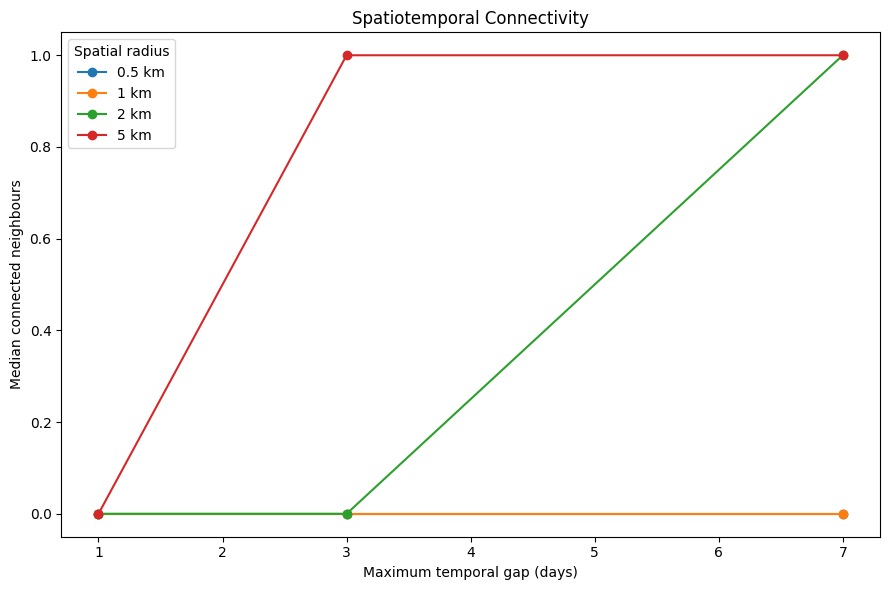

In [22]:
plt.figure(figsize=(9, 6))

for radius in [0.5, 1, 2, 5]:

    subset = combined_results[
        combined_results["radius_km"] == radius
    ]

    plt.plot(
        subset["temporal_gap_days"],
        subset["median_neighbours"],
        marker="o",
        label=f"{radius} km"
    )

plt.xlabel("Maximum temporal gap (days)")
plt.ylabel("Median connected neighbours")

plt.title(
    "Spatiotemporal Connectivity"
)

plt.legend(title="Spatial radius")
plt.tight_layout()
plt.show()

In [23]:
poc_candidate = combined_results[
    (combined_results["radius_km"] == 1) &
    (combined_results["temporal_gap_days"] == 3)
]

display(poc_candidate)

,radius_km,temporal_gap_days,mean_neighbours,median_neighbours,p90_neighbours,p95_neighbours,isolated_percent
4,1.0000,3,0.6788,0.0000,2.0000,3.0000,64.5967


In [24]:
radius_km = 1
temporal_gap = 3

radius_rad = (
    radius_km / EARTH_RADIUS_KM
)

neighbour_lists = event_tree.query_radius(
    event_coords_rad,
    r=radius_rad
)

connectivity = []

for i, neighbours in enumerate(
    neighbour_lists
):

    candidate_dates = (
        event_sample
        .iloc[neighbours]["acq_date"]
    )

    date_difference = (
        candidate_dates
        - event_sample.iloc[i]["acq_date"]
    ).abs().dt.days

    connected = (
        (date_difference <= temporal_gap)
        .sum() - 1
    )

    connectivity.append(
        connected
    )

event_sample["connected_neighbours_1km_3day"] = (
    connectivity
)

display(
    event_sample[
        [
            "latitude",
            "longitude",
            "acq_date",
            "frp",
            "connected_neighbours_1km_3day"
        ]
    ]
    .sort_values(
        "connected_neighbours_1km_3day",
        ascending=False
    )
    .head(20)
)

,latitude,longitude,acq_date,frp,connected_neighbours_1km_3day
26612,23.7701,86.3912,2024-01-13,1.8000,12
4040,29.9073,74.9482,2023-01-04,16.7800,12
9685,29.9098,74.9461,2023-01-07,17.0800,12
376,29.9114,74.9510,2023-01-04,14.4100,11
3563,23.7653,86.3958,2023-12-26,1.6800,11
8811,23.7716,86.3955,2024-01-13,1.5600,11
26737,29.9082,74.9468,2023-01-09,6.2000,11
18989,29.9111,74.9512,2023-01-07,41.4300,11
14270,23.7721,86.3967,2024-01-11,1.3400,10
25592,23.7660,86.3975,2023-11-09,3.6100,10


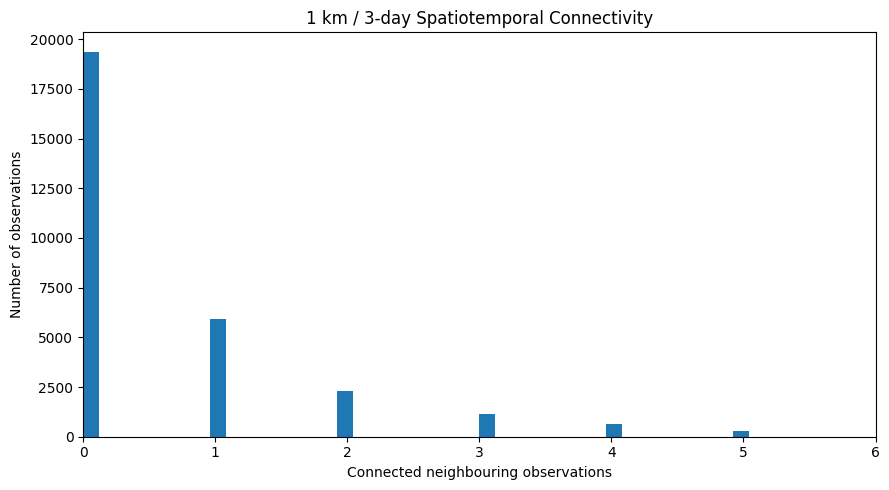

In [25]:
plt.figure(figsize=(9, 5))

plt.hist(
    event_sample[
        "connected_neighbours_1km_3day"
    ],
    bins=100
)

plt.xlim(
    0,
    event_sample[
        "connected_neighbours_1km_3day"
    ].quantile(0.99)
)

plt.title(
    "1 km / 3-day Spatiotemporal Connectivity"
)

plt.xlabel("Connected neighbouring observations")
plt.ylabel("Number of observations")

plt.tight_layout()
plt.show()

In [26]:
radius_results.to_csv(
    "viirs_spatial_radius_comparison.csv",
    index=False
)

same_day_results.to_csv(
    "viirs_same_day_spatial_comparison.csv",
    index=False
)

temporal_summary.to_csv(
    "viirs_temporal_continuity_summary.csv",
    index=False
)

combined_results.to_csv(
    "viirs_spatiotemporal_parameter_comparison.csv",
    index=False
)

print("Spatial EDA diagnostics saved.")

Spatial EDA diagnostics saved.
